In [5]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/db/bluestock_mf.db')

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

tables

,name
0,01_fund_master_clean
1,02_nav_history_clean
2,03_aum_by_fund_house_clean
3,04_monthly_sip_inflows_clean
4,05_category_inflows_clean
5,06_industry_folio_count_clean
6,07_scheme_performance_clean
7,08_investor_transactions_clean
8,09_portfolio_holdings_clean
9,10_benchmark_indices_clean


In [7]:
nav_history = pd.read_sql(
    'SELECT * FROM "02_nav_history_clean"',
    conn
)

investor_txn = pd.read_sql(
    'SELECT * FROM "08_investor_transactions_clean"',
    conn
)

portfolio = pd.read_sql(
    'SELECT * FROM "09_portfolio_holdings_clean"',
    conn
)

In [8]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [9]:
investor_txn.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [10]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [11]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [12]:
investor_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [13]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [14]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

nav_history = nav_history.sort_values(
    ['amfi_code', 'date']
)

nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [15]:
var_report = (
    nav_history.groupby('amfi_code')['daily_return']
    .apply(lambda x: np.percentile(x.dropna(), 5))
    .reset_index()
)

var_report.columns = ['amfi_code', 'VaR_95']

var_report.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [16]:
def calculate_cvar(x):
    x = x.dropna()

    var95 = np.percentile(x, 5)

    return x[x <= var95].mean()

cvar_report = (
    nav_history.groupby('amfi_code')['daily_return']
    .apply(calculate_cvar)
    .reset_index()
)

cvar_report.columns = ['amfi_code', 'CVaR']

cvar_report.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [17]:
risk_report = pd.merge(
    var_report,
    cvar_report,
    on='amfi_code'
)

risk_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [18]:
risk_report.to_csv(
    '../reports/var_cvar_report.csv',
    index=False
)

print("Saved Successfully")

Saved Successfully


In [19]:
risk_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [20]:
nav_history['rolling_mean'] = (
    nav_history.groupby('amfi_code')['daily_return']
    .transform(lambda x: x.rolling(90).mean())
)

nav_history['rolling_std'] = (
    nav_history.groupby('amfi_code')['daily_return']
    .transform(lambda x: x.rolling(90).std())
)

nav_history['rolling_sharpe'] = (
    nav_history['rolling_mean']
    /
    nav_history['rolling_std']
) * np.sqrt(252)

nav_history.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [21]:
top5_funds = (
    nav_history.groupby('amfi_code')['rolling_sharpe']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top5_funds

amfi_code
120507    13.558546
120844    12.478178
101208    11.995642
120843     1.997692
148567     1.890422
Name: rolling_sharpe, dtype: float64

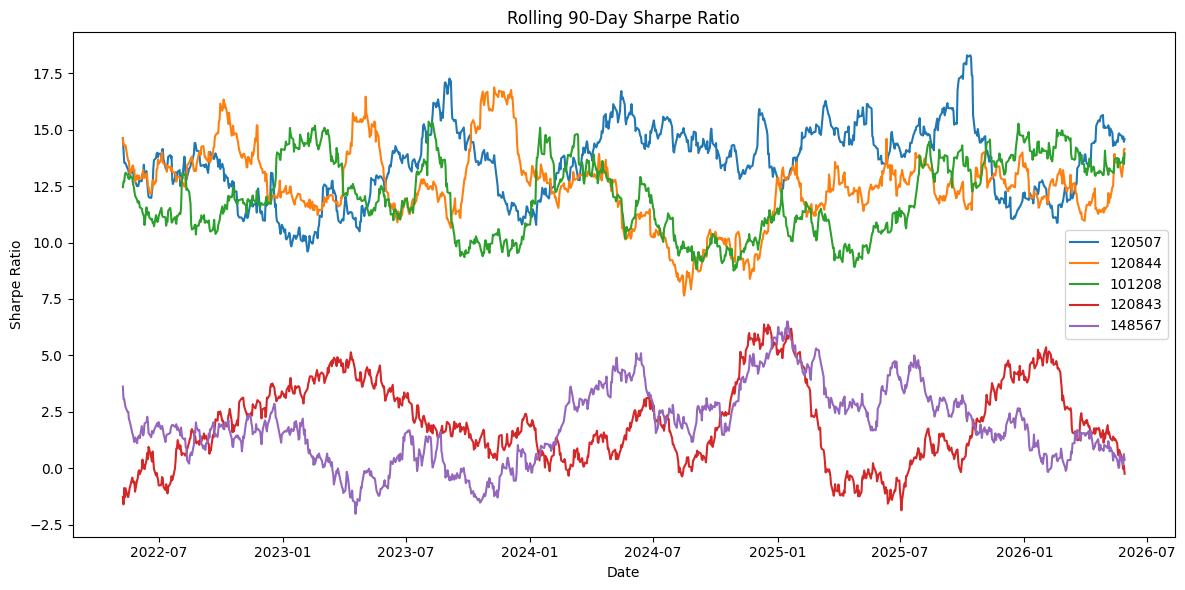

In [22]:
plt.figure(figsize=(12,6))

for fund in top5_funds.index:
    
    temp = nav_history[
        nav_history['amfi_code'] == fund
    ]
    
    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [23]:
top_sharpe = (
    nav_history.groupby('amfi_code')['rolling_sharpe']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_sharpe.to_csv(
    "../reports/top10_sharpe.csv",
    index=False
)

top_sharpe.head()

,amfi_code,rolling_sharpe
0,120507,13.558546
1,120844,12.478178
2,101208,11.995642
3,120843,1.997692
4,148567,1.890422


In [24]:
investor_txn['transaction_date'] = pd.to_datetime(
    investor_txn['transaction_date']
)

cohort = (
    investor_txn.groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

cohort['cohort_year'] = cohort['transaction_date'].dt.year

cohort.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [25]:
investor_txn = investor_txn.merge(
    cohort[['investor_id','cohort_year']],
    on='investor_id',
    how='left'
)

investor_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [26]:
cohort_report = (
    investor_txn.groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum'),
        investor_count=('investor_id','nunique')
    )
    .reset_index()
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [27]:
cohort_report.to_csv(
    '../reports/cohort_analysis.csv',
    index=False
)

print("Cohort Analysis Saved")

Cohort Analysis Saved


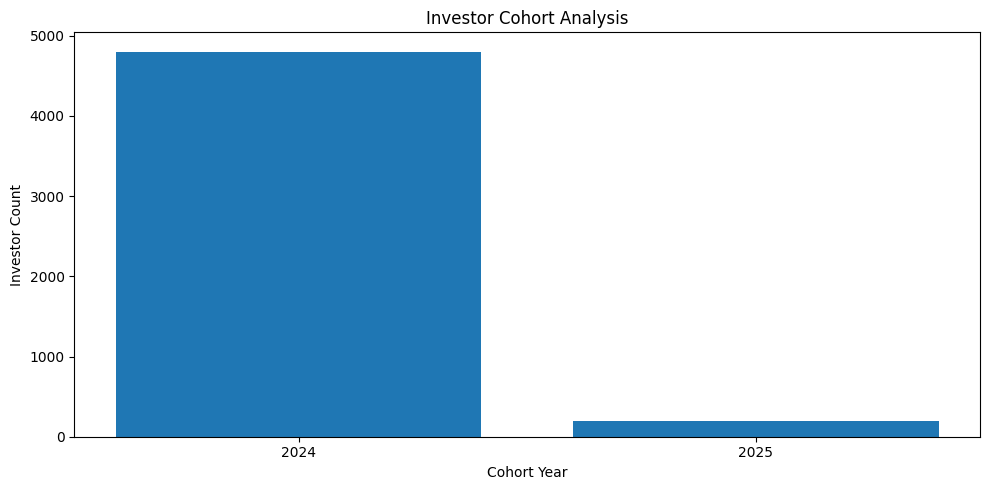

In [28]:
plt.figure(figsize=(10,5))

plt.bar(
    cohort_report['cohort_year'].astype(str),
    cohort_report['investor_count']
)

plt.title("Investor Cohort Analysis")
plt.xlabel("Cohort Year")
plt.ylabel("Investor Count")

plt.tight_layout()

plt.savefig(
    "../reports/cohort_analysis.png"
)

plt.show()

TASK 4: SIP Continuity Analysis

In [29]:
sip_txn = investor_txn[
    investor_txn['transaction_type'] == 'SIP'
].copy()

sip_txn['transaction_date'] = pd.to_datetime(
    sip_txn['transaction_date']
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [30]:
sip_txn = sip_txn.sort_values(
    ['investor_id','transaction_date']
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [31]:
sip_count = (
    sip_txn.groupby('investor_id')
    .size()
    .reset_index(name='sip_count')
)

eligible_investors = sip_count[
    sip_count['sip_count'] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [35]:
avg_gap = (
    sip_txn.groupby('investor_id')['gap_days']
    .mean()
    .reset_index()
)

avg_gap.columns = [
    'investor_id',
    'avg_gap_days'
]

avg_gap.head()

,investor_id,avg_gap_days
0,INV000001,76.0
1,INV000002,207.0
2,INV000003,238.0
3,INV000004,85.4
4,INV000005,14.0


In [36]:
sip_risk = (
    eligible_investors
    .merge(avg_gap,on='investor_id')
)

sip_risk['risk_status'] = np.where(
    sip_risk['avg_gap_days'] > 35,
    'At Risk',
    'Healthy'
)

sip_risk.head()

,investor_id,sip_count,avg_gap_days,risk_status
0,INV000004,6,85.400000,At Risk
1,INV000008,6,70.400000,At Risk
2,INV000010,6,64.800000,At Risk
3,INV000011,7,40.166667,At Risk
4,INV000012,8,57.000000,At Risk


In [37]:
sip_risk.to_csv(
    '../reports/sip_continuity_report.csv',
    index=False
)

print("SIP Continuity Report Saved")

SIP Continuity Report Saved


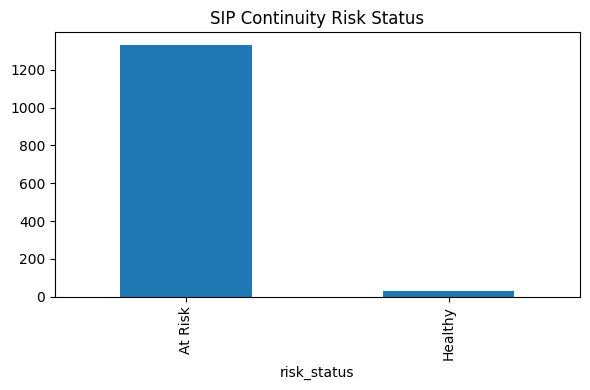

In [38]:
risk_count = (
    sip_risk['risk_status']
    .value_counts()
)

plt.figure(figsize=(6,4))

risk_count.plot(
    kind='bar'
)

plt.title("SIP Continuity Risk Status")

plt.tight_layout()

plt.savefig(
    "../reports/sip_continuity.png"
)

plt.show()

TASK 5: Simple Fund Recommender

In [39]:
scheme_perf = pd.read_sql(
    'SELECT * FROM "07_scheme_performance_clean"',
    conn
)

scheme_perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [40]:
scheme_perf.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

TASK 5: Fund Recommender

In [43]:
def recommend_funds(risk_level):

    rec = (
        scheme_perf[
            scheme_perf['risk_grade'].str.lower()
            ==
            risk_level.lower()
        ]
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    return rec[
        [
            'scheme_name',
            'fund_house',
            'risk_grade',
            'sharpe_ratio'
        ]
    ]

In [44]:
recommend_funds('Low')

,scheme_name,fund_house,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14


In [45]:
recommend_funds('Moderate')

,scheme_name,fund_house,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03


In [46]:
recommend_funds('High')

,scheme_name,fund_house,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,High,0.90


In [47]:
low = recommend_funds('Low')
moderate = recommend_funds('Moderate')
high = recommend_funds('High')

all_recommendations = pd.concat(
    [low, moderate, high]
)

all_recommendations.to_csv(
    '../reports/fund_recommendations.csv',
    index=False
)

print("Recommendations Saved")

Recommendations Saved


TASK 6: Sector HHI Concentration

In [48]:
portfolio['weight_decimal'] = (
    portfolio['weight_pct'] / 100
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_decimal
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [49]:
hhi_report = (
    portfolio.groupby('amfi_code')
    .apply(
        lambda x:
        (x['weight_decimal'] ** 2).sum()
    )
    .reset_index(name='HHI')
)

hhi_report.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [50]:
hhi_report = hhi_report.sort_values(
    'HHI',
    ascending=False
)

hhi_report.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [51]:
hhi_report.to_csv(
    '../reports/sector_hhi_report.csv',
    index=False
)

print("HHI Report Saved")

HHI Report Saved


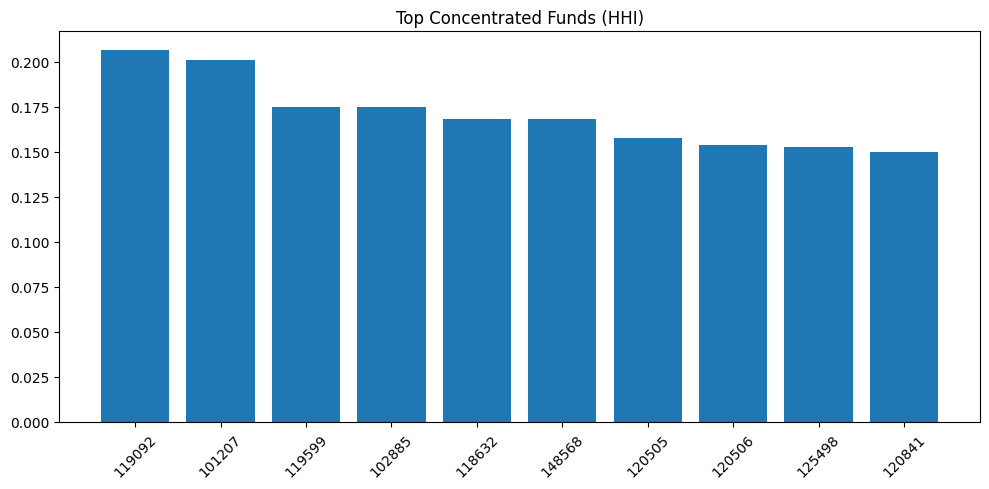

In [52]:
top10_hhi = hhi_report.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10_hhi['amfi_code'].astype(str),
    top10_hhi['HHI']
)

plt.title("Top Concentrated Funds (HHI)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../reports/hhi_chart.png'
)

plt.show()

# Advanced Analytics Insights

## Insight 1: Risk Analysis
Several mutual funds exhibit significantly higher VaR and CVaR values, indicating greater downside risk during adverse market conditions. Investors with lower risk tolerance should avoid funds with highly negative VaR values.

## Insight 2: Sharpe Ratio Performance
The top-ranked funds by rolling Sharpe Ratio consistently generated better risk-adjusted returns. These funds provided superior returns for each unit of risk taken.

## Insight 3: Investor Cohort Behaviour
The majority of investors belong to the 2024 cohort, indicating strong recent participation in mutual fund investments. New investor acquisition increased significantly during this period.

## Insight 4: SIP Continuity Risk
A large proportion of investors were classified as "At Risk" due to long gaps between SIP transactions. This highlights the need for investor engagement and retention strategies.

## Insight 5: Portfolio Concentration
Funds with higher HHI values are more concentrated in a limited number of sectors or holdings. While concentration can improve returns during favorable conditions, it also increases portfolio-specific risk.